# Rag From Scratch: Query Transformations

Query transformations are a set of approaches focused on re-writing and / or modifying questions for retrieval.
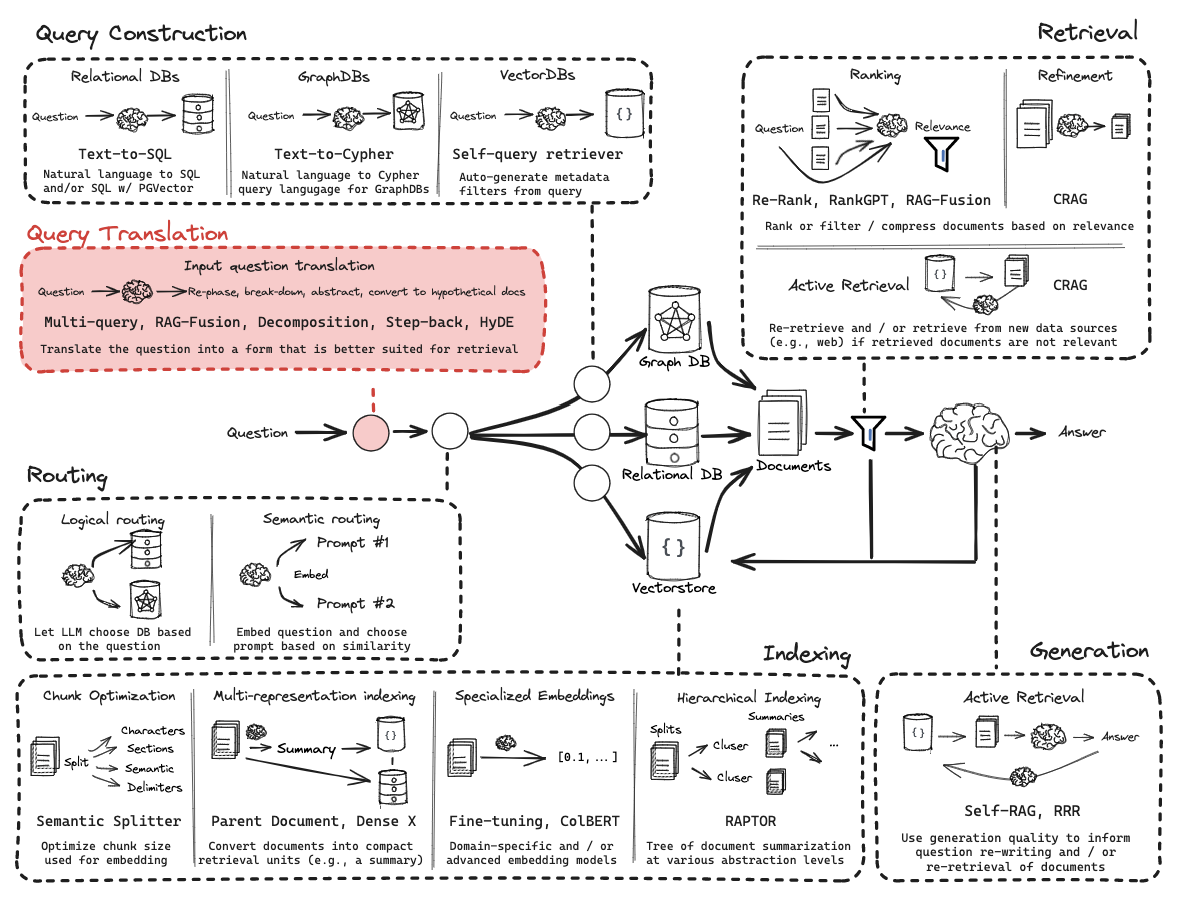

## Environment

In [6]:
import os
os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ['LANGCHAIN_API_KEY'] = "<your-api-key>"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
# Set a User-Agent for polite web requests (helps with some sites)
os.environ["USER_AGENT"] = "rag-from-scratch/1.0 (+mailto:your-email@example.com)"

## Part 5: Multi Query

Flow:
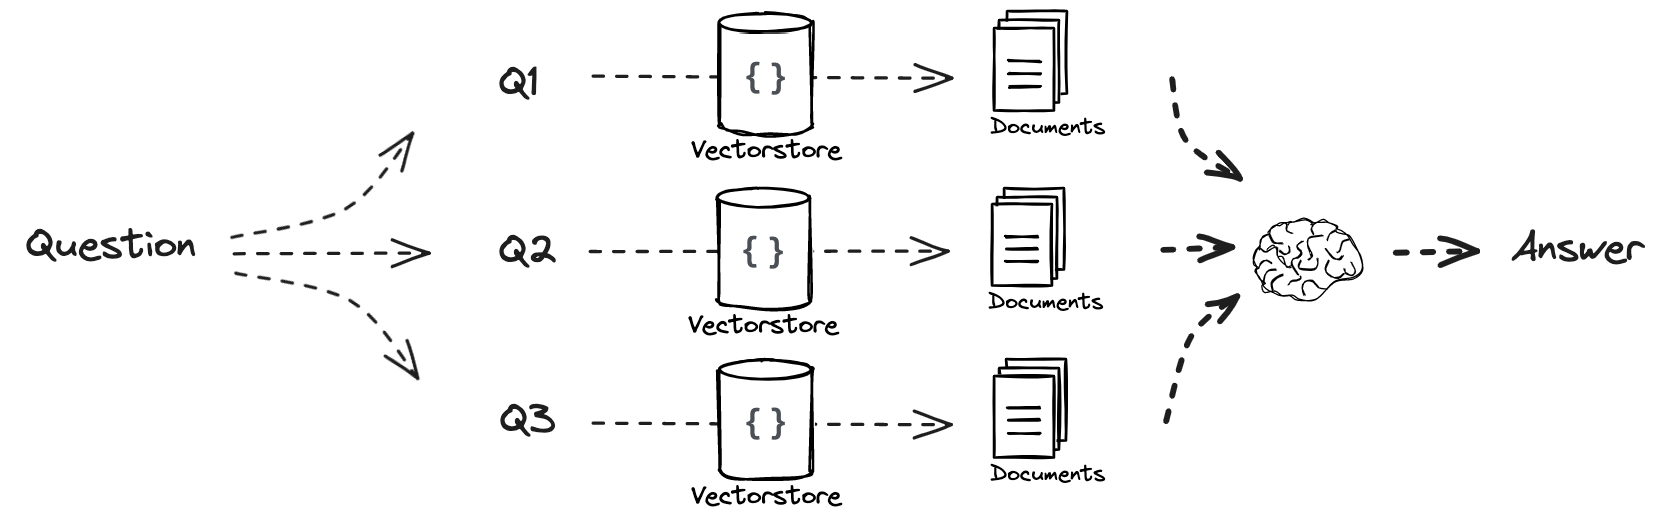
Docs:

* https://python.langchain.com/docs/modules/data_connection/retrievers/MultiQueryRetriever

### Index

In [16]:
import os
import bs4

from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

# Load documents from the web
loader = WebBaseLoader(
    web_paths=["https://lilianweng.github.io/posts/2023-06-23-agent/"],
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=["post-content", "post-title", "post-header"]
        )
    ),
)
docs = loader.load()

# Model
chat_model = ChatOpenAI(
    model="qwen-plus",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
    temperature=0,
)

# Split documents into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=300,
    chunk_overlap=50
)
splits = text_splitter.split_documents(docs)

# index
embd_model = OpenAIEmbeddings(
    model="text-embedding-v3",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
    chunk_size=10,
    check_embedding_ctx_length=False,
)
vectorstore = FAISS.from_documents(
    documents=splits,
    embedding=embd_model,
)
retriever = vectorstore.as_retriever()


AttributeError: module 'faiss' has no attribute 'IndexFlatL2'

### Prompt

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# Multi Query: Different Perspectives
template = """You are an AI language model assistant. Your task is to generate five 
different versions of the given user question to retrieve relevant documents from a vector 
database. By generating multiple perspectives on the user question, your goal is to help
the user overcome some of the limitations of the distance-based similarity search. 
Provide these alternative questions separated by newlines. Original question: {question}"""

prompt_perspectives = ChatPromptTemplate.from_template(template)

generate_queries = (
    prompt_perspectives
    | chat_model
    | StrOutputParser()
    | (lambda output: output.split("\n"))
)

In [9]:
from langchain_core.load import dumps, loads

def get_unique_union(documents: list[list]):
    #flatten the list of lists into a single list of documents
    flattened_docs = [dumps(doc) for sublist in documents for doc in sublist]
    # Use set to get unique documents based on their string representation
    unique_docs = list(set(flattened_docs))
    return [loads(doc) for doc in unique_docs]

#retrieve
question = "What is task decomposition for LLMs?"
retrieve_chain = generate_queries | retriever.map() | get_unique_union
retrieved_docs = retrieve_chain.invoke({"question": question})
len(retrieved_docs)

C:\Users\zhengjiayu\AppData\Local\Temp\ipykernel_2656\1742018171.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  return [loads(doc) for doc in unique_docs]


11

In [7]:
from operator import itemgetter
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough

# RAG
template = """Answer the following question based on this context:

{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_chain = (
    {"context": retrieve_chain,
     "question": itemgetter("question")}
    | prompt
    | chat_model
    | StrOutputParser()
)

final_rag_chain.invoke({"question": question})

C:\Users\zhengjiayu\AppData\Local\Temp\ipykernel_2656\1742018171.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  return [loads(doc) for doc in unique_docs]


'Task decomposition for LLMs is the process of breaking down a large, complex task into smaller, simpler, and more manageable subgoals or steps. As stated in the documents:\n\n- “Subgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.”  \n- “CoT transforms big tasks into multiple manageable tasks…”  \n- Task decomposition can be performed in several ways:  \n  (1) by the LLM itself using simple prompting (e.g., “Steps for XYZ.\\n1.” or “What are the subgoals for achieving XYZ?”),  \n  (2) via task-specific instructions (e.g., “Write a story outline.”), or  \n  (3) with human inputs.  \n- In structured agent systems, this occurs during *task planning*, where the LLM acts as the “brain” to parse user requests into multiple tasks—each with attributes like task type, ID, dependencies, and arguments—often guided by few-shot examples.\n\nIn essence, task decomposition enhances reasoning, improves interpreta

## Part 6: RAG-Fusion

Flow:
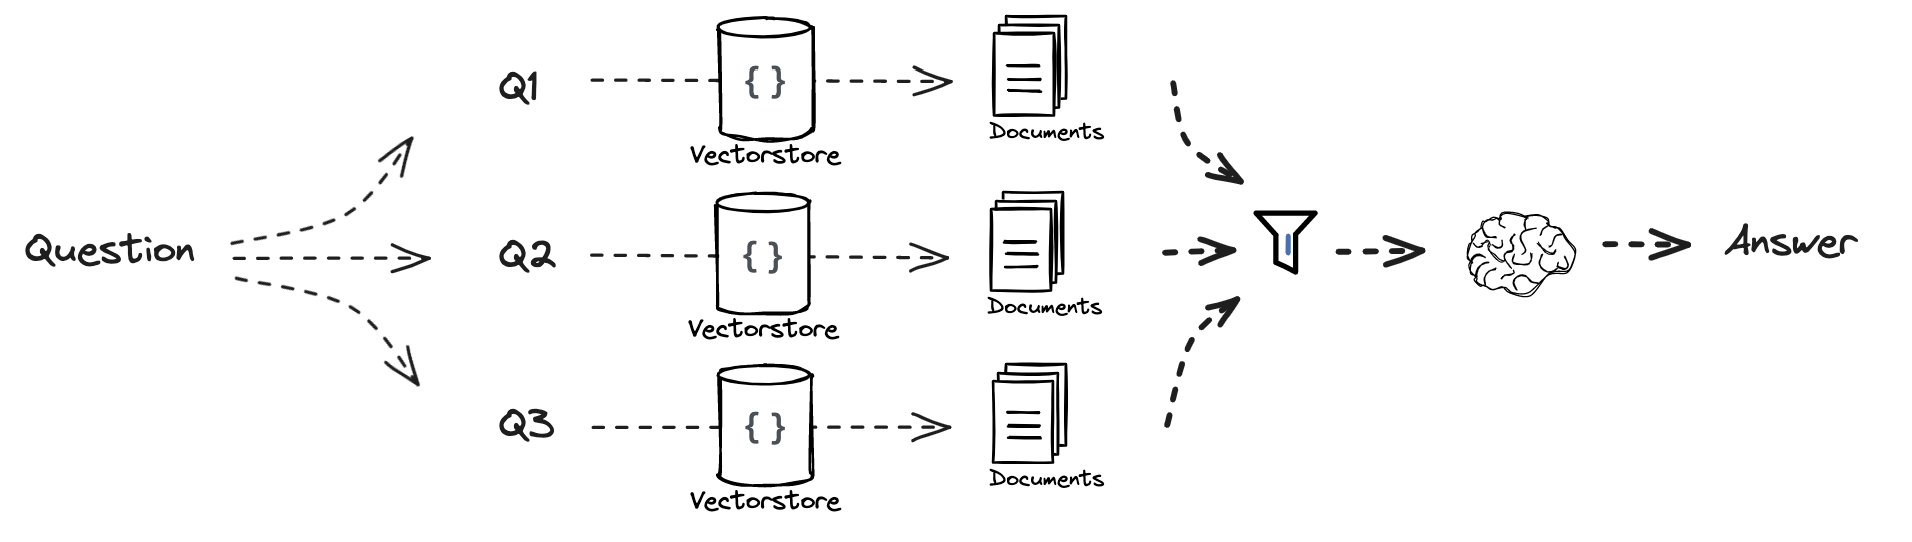


Blog / repo: 

* https://towardsdatascience.com/forget-rag-the-future-is-rag-fusion-1147298d8ad1

### Prompt

In [8]:
from langchain_core.prompts import ChatPromptTemplate

template = """You are a helpful assistant that generates multiple search queries based on a single input query. \n
Generate multiple search queries related to: {question} \n
Output (4 queries):"""
prompt_rag_fusion = ChatPromptTemplate.from_template(template)

In [ ]:
from langchain_core.output_parsers import StrOutputParser

generate_queries = (
    prompt_rag_fusion
    | chat_model
    | StrOutputParser()
    | (lambda output: output.split("\n"))
)

In [11]:
from langchain_core.load import dumps, loads

def reciprocal_rank_fusion(results: list[list], k=60) -> list[tuple[dict, float]]: 
    fused_scores = {}
    for docs in results:
        for rank, doc in enumerate(docs):
            # Calculate the reciprocal rank score for the document
            doc_str = dumps(doc)
            if doc_str not in fused_scores:
                fused_scores[doc_str] = 0
            # Update the score of the document using the RRF formula: 1 / (rank + k)
            fused_scores[doc_str] +=  1 / (rank + k)

    reranked_results = [
        (loads(doc), score) 
        for doc, score in sorted(fused_scores.items(), key=lambda x: x[1], reverse=True)
    ]

    return reranked_results

retrieve_chain_rag_fusion = generate_queries | retriever.map() | reciprocal_rank_fusion
docs = retrieve_chain_rag_fusion.invoke({"question": question})
len(docs)

C:\Users\zhengjiayu\AppData\Local\Temp\ipykernel_2656\1702963928.py:15: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  (loads(doc), score)


10

In [12]:
from langchain_core.runnables import RunnablePassthrough

# RAG
template = """Answer the following question based on this context:

{context}

Question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

final_rag_fusion_chain = (
    {"context": retrieve_chain_rag_fusion,
     "question": itemgetter("question")}
    | prompt
    | chat_model
    | StrOutputParser()
)
final_rag_fusion_chain.invoke({"question": question})

C:\Users\zhengjiayu\AppData\Local\Temp\ipykernel_2656\1702963928.py:15: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit list of allowed classes (or 'messages' for untrusted input that contains only chat messages) to suppress this warning.
  (loads(doc), score)


'Task decomposition for LLMs is the process of breaking down a large, complex task into smaller, simpler, and more manageable subgoals or steps—enabling efficient planning, reasoning, and execution. As described in the context:\n\n- It can be performed in multiple ways:  \n  (1) **Using simple prompting**, such as asking the LLM “Steps for XYZ.” or “What are the subgoals for achieving XYZ?”  \n  (2) **Via task-specific instructions**, e.g., “Write a story outline.” for novel writing;  \n  (3) **With human inputs**, where users explicitly guide or refine the decomposition.\n\n- It is closely related to **Chain of Thought (CoT)** prompting (Wei et al., 2022), where the model is instructed to “think step by step,” leveraging additional test-time computation to decompose hard tasks into sequential, interpretable steps.\n\n- In agent systems, task decomposition is formalized during **task planning**, where the LLM acts as the “brain” to parse user requests into structured tasks—each with at

## Part 7: Decomposition

In [13]:
from langchain_core.prompts import ChatPromptTemplate

# Decomposition
template = """You are a helpful assistant that generates multiple sub-questions related to an input question. \n
The goal is to break down the input into a set of sub-problems / sub-questions that can be answers in isolation. \n
Generate multiple search queries related to: {question} \n
Output (3 queries):"""
prompt_decomposition = ChatPromptTemplate.from_template(template)

In [19]:
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser

# Model
chat_model = ChatOpenAI(
    model="qwen-plus",
    api_key=os.getenv("DASHSCOPE_API_KEY"),
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
    temperature=0,
)

# chain
generate_queries_decomposition = (
    prompt_decomposition
    | chat_model
    | StrOutputParser()
    | (lambda output: output.split("\n"))
)

#Run
question = "What are the main components of an LLM-powered autonomous agent system?"
questions = generate_queries_decomposition.invoke({"question":question})

In [20]:
questions

['1. What are the core architectural components of an LLM-powered autonomous agent (e.g., planner, memory, tool use, executor)?  ',
 '2. How does long-term and short-term memory function in LLM-based autonomous agents?  ',
 '3. What role do external tools, APIs, and action executors play in enabling autonomy for LLM agents?']

### Answer recursively  
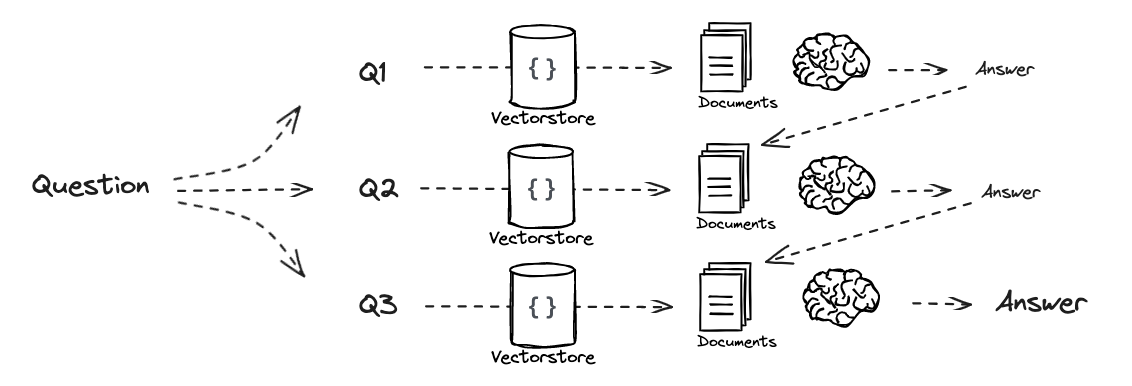
Papers:

* https://arxiv.org/pdf/2205.10625.pdf
* https://arxiv.org/abs/2212.10509.pdf

In [27]:
# Prompt
template = """Here is the question you need to answer:

\n --- \n {question} \n --- \n

Here is any available background question + answer pairs:

\n --- \n {qa_pairs} \n --- \n

Here is additional context relevant to the question: 

\n --- \n {context} \n --- \n

Use the above context and any background question + answer pairs to answer the question: \n {question}
"""

decomposition_prompt = ChatPromptTemplate.from_template(template)

In [28]:
from operator import itemgetter
from langchain_core.output_parsers import StrOutputParser

def format_qa_pair(question, answer):
    formatted_string = ""
    formatted_string += f"Question: {question}\nAnswer: {answer}\n\n"
    return formatted_string.strip()

qa_pairs = ""
for q in questions:

    rag_chain = (
        {"context": itemgetter("question") | retriever,
         "question": itemgetter("question"),
         "qa_pairs": itemgetter("qa_pairs")}
        | decomposition_prompt
        | chat_model
        | StrOutputParser()
    )

    answer = rag_chain.invoke({"question": q, "qa_pairs": qa_pairs})
    qa_pair = format_qa_pair(q, answer)
    qa_pairs += qa_pair + "\n---\n"

answer

'External tools, APIs, and action executors are **the critical enablers of *real-world agency***—transforming LLMs from passive text predictors into autonomous agents capable of *perceiving, acting upon, and changing their environment*. As emphasized in Lilian Weng’s foundational architecture and corroborated by the background answers, they collectively constitute the **“action interface” and “executor” components**, bridging the LLM’s symbolic reasoning with tangible, external effects. Their roles in enabling autonomy are threefold:\n\n### 1. **Extending Capabilities Beyond Language Generation**  \nLLMs are inherently *stateless, offline, and knowledge-bounded*: they cannot access real-time data, execute code, modify files, control devices, or interact with live systems. External tools and APIs (e.g., web search, Python interpreters, database connectors, robotics APIs, calendar services) **endow the agent with sensory and motor functions**—effectively granting it *eyes, hands, and ear

### Answer individually 
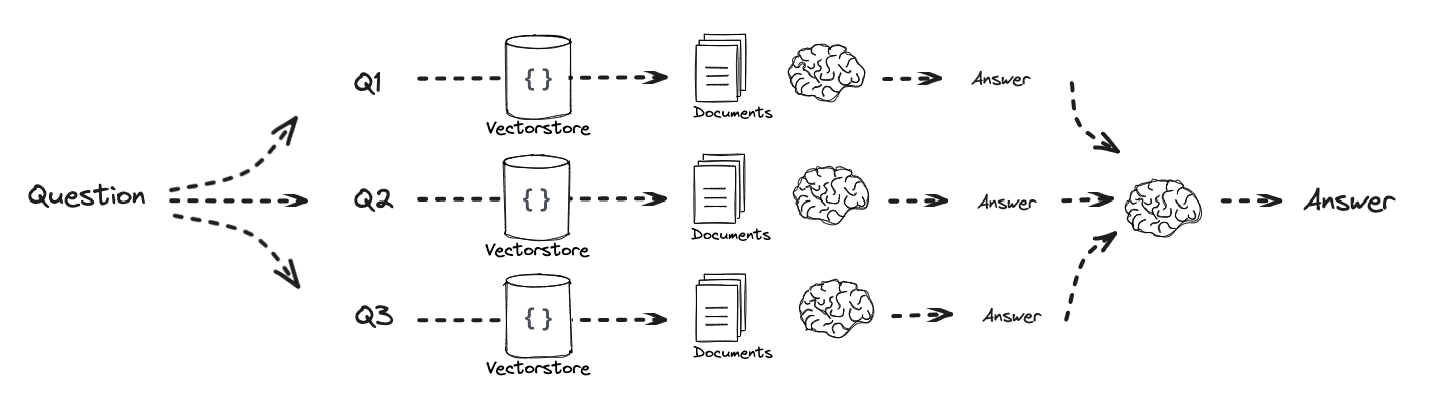

In [36]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough, RunnableLambda
from langchain_core.output_parsers import StrOutputParser
from langchain_openai import ChatOpenAI

# RAG prompt
prompt_rag = ChatPromptTemplate.from_template(
    """Answer the following question based on this context:

{context}

Question: {question}"""
)

def retrieve_and_rag(question, prompt_rag, sub_question_rag_chain):
    """RAG on each sub-question"""

    # decomposition
    sub_questions = sub_question_rag_chain.invoke({"question": question})

    # initialize a list to hold RAG chain results
    rag_results = []

    for sub_question in sub_questions:
        # retrieve docs for the sub-question
        retrieved_docs = retriever.invoke(sub_question)
        
        # invoke the RAG chain and store the result
        rag_tmp_chain = prompt_rag | chat_model | StrOutputParser()
        answer = rag_tmp_chain.invoke({
            "context": retrieved_docs,
            "question": sub_question
        })
        rag_results.append(answer)

    return rag_results, sub_questions

# wrap the retrieval and RAG process in a RunnableLambda for intergration into the overall chain
answers, questions = retrieve_and_rag(question, prompt_rag, generate_queries_decomposition)


In [3]:
def format_qa_pair(question, answer):
    """Format a question and answer pair into a string."""

    formatted_string = ""
    for i, (question, answer) in enumerate(zip(questions, answers), start=1):
        formatted_string += f"Question {i}: {question}\nAnswer {i}: {answer}\n\n"
    return formatted_string.strip()

context = format_qa_pair(questions, answers)

# prompt for the final answer generation
template = """Here is a set of Q+A pairs:

{context}

Use these to synthesize an answer to the question: {question}
"""

prompt = ChatPromptTemplate.from_template(template)

final_answer_chain = (
    prompt
    | chat_model
    | StrOutputParser()
)
final_answer = final_answer_chain.invoke({
    "context": context,
    "question": question
})  

NameError: name 'questions' is not defined

## Part 8: Step Back
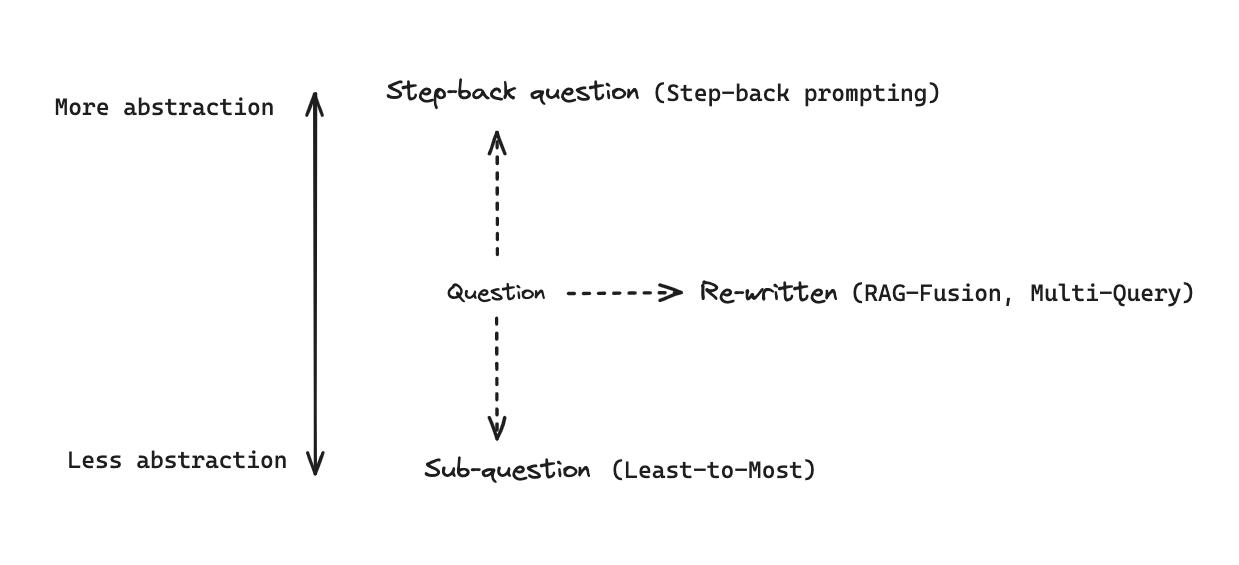

Paper: 

* https://arxiv.org/pdf/2310.06117.pdf

In [1]:
# Few Shot Examples
from langchain_core.prompts import ChatPromptTemplate, FewShotChatMessagePromptTemplate

examples = [
    {
        "input": "Could the members of The Police perform lawful arrests?",
        "output": "what can the members of The Police do?",
    },
    {
        "input": "Jan Sindel’s was born in what country?",
        "output": "what is Jan Sindel’s personal history?",
    },
]
# We now transform these to example messages
example_prompt = ChatPromptTemplate.from_messages(
    [
        ("human", "{input}"),
        ("ai", "{output}"),
    ]
)
few_shot_prompt = FewShotChatMessagePromptTemplate(
    example_prompt=example_prompt,
    examples=examples,
)
prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are an expert at world knowledge. Your task is to step back and paraphrase a question to a more generic step-back question, which is easier to answer. Here are a few examples:""",
        ),
        # Few shot examples
        few_shot_prompt,
        # New question
        ("user", "{question}"),
    ]
)

In [9]:
from langchain_core.output_parsers import StrOutputParser

generate_queries_step_back = prompt | chat_model | StrOutputParser()
question = "What is task decomposition for LLM agents?"
generate_queries_step_back.invoke({"question": question})

'What is the concept of task decomposition in the context of LLM-based agents?'

In [11]:
from langchain_core.runnables import RunnableLambda

# Response prompt 
response_prompt_template = """You are an expert of world knowledge. 
    I am going to ask you a question. 
    Your response should be comprehensive and not contradicted with the following context if they are relevant. 
    Otherwise, ignore them if they are not relevant.

    # {normal_context}
    # {step_back_context}

    # Original Question: {question}
    # Answer:"""

response_prompt = ChatPromptTemplate.from_template(response_prompt_template)

chain = (
    {
        # Retrieve context using the normal question
        "normal_context": RunnableLambda(lambda x: x["question"]) | retriever,
        # Retrieve context using the step-back question
        "step_back_context": generate_queries_step_back | retriever,
        # Pass on the question
        "question": lambda x: x["question"],
    }
    | response_prompt
    | ChatOpenAI(temperature=0)
    | StrOutputParser()
)

chain.invoke({"question": question})


NameError: name 'retriever' is not defined